# 使用Python实现线性回归

## 1.导入相关包

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rich import color
from sklearn.linear_model import LinearRegression

## 2.生成模拟数据

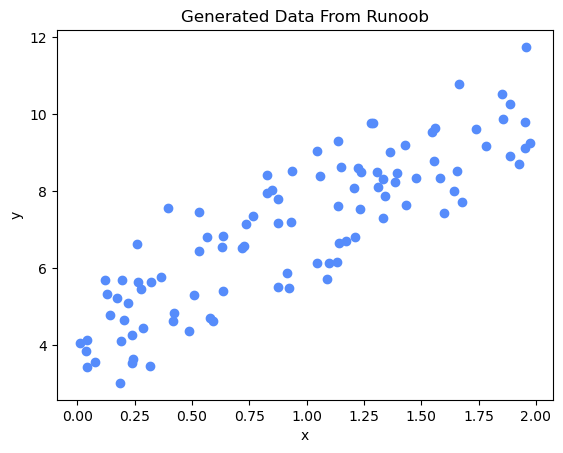

In [3]:
# 生成一些随机数据
np.random.seed(0)   # 设置随机数种子为0，固定随机序列，每次运行生成相同随机数据（可复现实验）
x = 2 * np.random.rand(100, 1)  # 生成100行1列的0~1随机数，乘以2，得到x取值范围：[0, 2)
# 构建线性回归模拟数据：y = 4 + 3x + 高斯噪声
# 4：截距，3：斜率
# np.random.randn(100,1)：生成标准正态分布噪声（均值0，方差1），模拟真实数据误差
y = 4 + 3 * x + np.random.randn(100, 1)

# 可视化数据
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title('Generated Data From Runoob')
plt.show()

## 3、使用 Scikit-learn 进行线性回归

斜率 (w): 2.968467510701018
截距 (b): 4.222151077447232


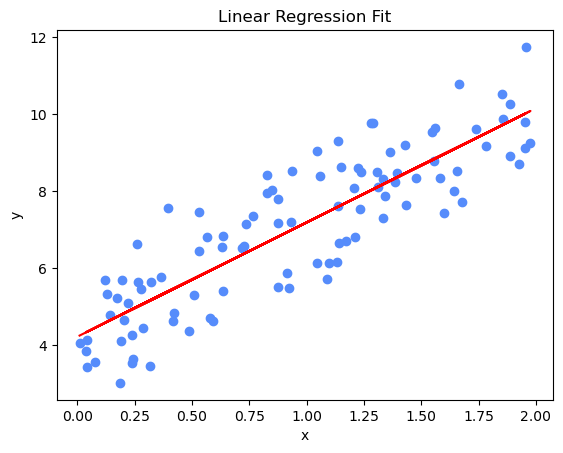

In [4]:
# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

# 创建线性回归模型
model = LinearRegression()

# 拟合模型,使用x、y训练模型，自动计算最优斜率和截距
model.fit(x, y)

# 输出模型的参数
print(f"斜率 (w): {model.coef_[0][0]}")
print(f"截距 (b): {model.intercept_[0]}")

# 预测
y_pred = model.predict(x)

# 可视化拟合结果,绘制原始真实数据散点
plt.scatter(x, y)
# 绘制模型拟合出的预测直线，红色
plt.plot(x, y_pred, color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title('Linear Regression Fit')
plt.show()

In [5]:
# 我们可以使用 score() 方法来评估模型性能，返回 R^2 值
score = model.score(x, y)
print(f"模型得分: {score}")

模型得分: 0.7469629925504755


## 手动实现梯度下降法

手动实现的斜率 (w): 2.968467510701028
手动实现的截距 (b): 4.222151077447219


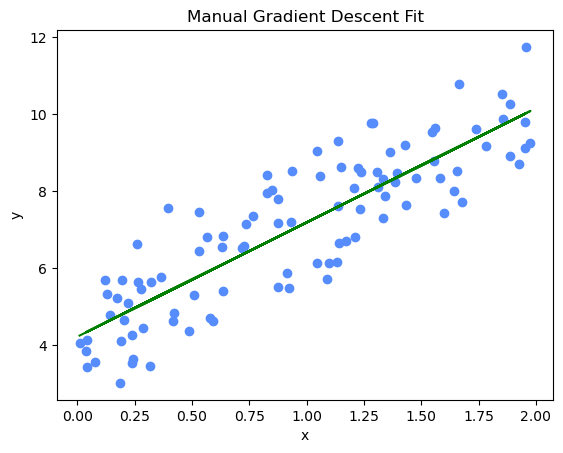

In [6]:
# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

# 初始化参数
w = 0
b = 0
# 学习率：控制每次参数更新的步长:太大容易震荡不收敛，太小收敛太慢
learning_rate = 0.1
# 梯度下降迭代总次数
n_iterations = 1000

# 梯度下降循环，重复迭代更新w、b
for  i in  range(n_iterations):
    # 根据当前w、b计算所有样本的预测值 y = w*x + b
    y_pred = w * x + b
    # 损失函数MSE对w求偏导（梯度dw）
    dw = -(2/len(x)) * np.sum(x * (y - y_pred))
    # 损失函数MSE对b求偏导（梯度db）
    db = -(2/len(x)) * np.sum(y - y_pred)
    # 沿梯度反方向更新斜率w
    w = w - learning_rate * dw
    # 沿梯度反方向更新截距b
    b = b - learning_rate * db

# 打印梯度下降训练完成后得到的参数
print(f"手动实现的斜率 (w): {w}")
print(f"手动实现的截距 (b): {b}")

# 用训练好的w,b计算全部样本的预测值
y_pred_manual = w * x + b
# 绘制原始真实数据散点
plt.scatter(x, y)
plt.plot(x,y_pred_manual,color='green')
plt.xlabel("x")
plt.ylabel("y")
plt.title('Manual Gradient Descent Fit')
plt.show()